## Customer lifetime value: joining purchase frequency and order value

For customer $i$ and a future horizon $H$, this notebook uses the standard decomposition

$$\widehat{CLV}_i(H)=\widehat{E[X_i(H)\mid\mathcal{H}_i]}	imes\widehat{E[M_i\mid\mathcal{H}_i]},$$

where $X_i(H)$ is the number of future orders and $M_i$ is the monetary value of a future order. The first expectation comes from the Pareto/NBD model fitted in `02_Purchase_Frequency.ipynb`; the second comes from the Gamma-Gamma model fitted here.

The notebook reads the cleaned order table `data/working_data/calib_order.csv` created by `01_Cleaning.ipynb` and `data/working_data/lifetimes.csv` generated by the Pareto/NBD workflow in `02_Purchase_Frequency.ipynb`. It fits Gamma-Gamma to calibration order amounts, tests the estimate on the later holdout period, merges expected order value with expected order count, and evaluates both individual-level error and business-relevant ranking. The final `df_clv` table contains each customer's calibration AOV, predicted AOV, predicted order count, predicted CLV, actual holdout CLV, and residual.

Gamma-Gamma is used because a customer's raw calibration average order value can be a noisy estimate of future spending, especially when the customer has made only a few purchases. A customer with one unusually large or unusually small basket can have a misleading historical average. Gamma-Gamma addresses this problem by shrinking each customer's monetary-value estimate toward the population pattern while still preserving evidence from that customer's own order history. This makes it a stronger monetary-value component for CLV than simply reusing the calibration average for every customer.

Gamma-Gamma models the monetary component only: it estimates the expected value of a customer's future order from that customer's earlier order amounts. It does not model whether the customer will purchase again or how many orders they will make; those quantities come from Pareto/NBD. The two forecasts are multiplied because CLV is the expected number of future orders times the expected value per future order. The model pairing follows [Fader, Hardie, and Lee (2005)](https://doi.org/10.1509/jmkr.2005.42.4.415), which combines a Pareto/NBD transaction model with a Gamma-Gamma monetary-value model for non-contractual CLV.

The holdout results support this division of labour. In the AOV back-test, the Gamma-Gamma estimate improves substantially over the historical-average comparison, while the notebook's 50:50 blend of Gamma-Gamma and calibration AOV provides the preferred monetary-value estimate used in the final CLV calculation. After the purchase-count and order-value forecasts are combined, predicted aggregate CLV is **6.91 million** against **6.73 million** realised, an overprediction of **2.62%**.

The main business result is the quality of the final customer ranking. When customers are ordered by predicted CLV, the top **1%** account for **29.35%** of realised holdout CLV; the top **5%** account for **44.76%**; the top **10%** account for **55.22%**; and the top **20%** account for **67.53%**. For comparison, random targeting would capture roughly 1%, 5%, 10%, and 20% of value at those same contact rates. The model therefore identifies a small group that contains a disproportionately large share of future revenue. This is the central practical finding: although an individual customer's exact CLV remains uncertain, the model provides a strong basis for prioritising limited retention or marketing resources.

## Summary of CLV results

This notebook combines two separate forecasts: Pareto/NBD supplies the expected number of future orders, and the Gamma-Gamma monetary-value model supplies the expected value of each order. The monetary-value validation shows why this extra modelling step is needed. A raw calibration AOV is easy to compute, but it is unstable for customers with limited purchase histories; Gamma-Gamma reduces that noise by borrowing strength from the full customer population. The notebook then uses a 50:50 blend of Gamma-Gamma and calibration AOV as the final AOV estimate.

The final CLV evaluation is strongest at the aggregate and ranking levels. Predicted total CLV is **6.91 million**, compared with **6.73 million** actual holdout CLV, an overprediction of only **2.62%**. Individual-level errors remain meaningful, so the model should not be interpreted as an exact revenue forecast for each customer. Its main value is prioritisation: the customers ranked highest by predicted CLV contain a much larger share of realised future value than random targeting would capture.

The cumulative-gains result is the clearest business summary. The top **1%** of customers by predicted CLV capture **29.35%** of actual CLV, the top **5%** capture **44.76%**, the top **10%** capture **55.22%**, and the top **20%** capture **67.53%**. This supports using the CLV model for retention targeting, customer tiering, and marketing-budget allocation, while still treating exact individual CLV values as uncertain estimates.

## Gamma-Gamma Monetary-Value Model: Mathematics, Assumptions, and Variables

The **Gamma-Gamma model** is a probabilistic model for customer monetary value. It describes how much a customer spends on each transaction and estimates the customer's underlying, long-run average transaction value from their observed purchase history.

**Model Assumptions:**

The Gamma-Gamma monetary-value model is based on the following assumptions:

* **A customer's underlying mean transaction value is relatively stable over the forecasting period.** The customer's typical spending level is assumed not to change systematically during the period for which the model is used.

* **Within-customer transaction values follow a Gamma distribution.** Each modeled transaction has a positive monetary value. Conditional on the customer's latent mean transaction value, individual transaction values are Gamma distributed.

* **Latent customer means follow a Gamma distribution.** The population distribution of customers' long-run average transaction values is modeled using a second Gamma distribution.


---
**The purpose of the Gamma-Gamma model is to estimate this latent quantity from the customer's observed transaction values while also using information from the overall customer population.:**
The model distinguishes between two sources of variation in transaction value:

1. **Within-customer variation:** The same customer may spend different amounts on different transactions.
2. **Between-customer variation:** Different customers may have systematically different typical transaction values.

This distinction allows the model to estimate a customer's expected future transaction value while accounting for uncertainty in their observed spending history.

**Observed Monetary History:**

For customer $i$, let
$
M_{ij}
$ denote the monetary value of customer $i$'s $j$th transaction.
Suppose customer $i$ has made $n_i$ observed transactions. Their observed monetary history is therefore
$
M_{i1},M_{i2},\ldots,M_{in_i}.
$
The customer's observed average transaction value is

$$
\bar M_i
=\frac{1}{n_i}
\sum_{j=1}^{n_i}M_{ij}.
$$

The model does not assume that this observed average is the customer's true long-run transaction value. Instead, it assumes that each customer has an unobserved, long-run mean transaction value, denoted by
$
\nu_i.
$


**Individual-Level Transaction-Value Distribution:**

Conditional on customer $i$'s latent long-run mean transaction value $\nu_i$, each transaction amount follows a Gamma distribution:

$$
M_{ij}\mid p,\nu_i
\sim
\operatorname{Gamma}
\left(
p,\text{ rate}=\frac{p}{\nu_i}
\right).
$$

Using the shape-rate parameterization, the probability density function is

$$
f(M_{ij}\mid p,\nu_i)
=\frac{
\left(\frac{p}{\nu_i}\right)^p
}{
\Gamma(p)
}
M_{ij}^{p-1}
\exp
\left(
-\frac{pM_{ij}}{\nu_i}
\right),
\qquad
M_{ij}>0.
$$

Here:

* $M_{ij}$ = monetary value of customer $i$'s $j$th transaction;
* $\nu_i$ = customer's latent long-run mean transaction value;
* $p>0$ = shape parameter controlling within-customer variation;
* $\Gamma(\cdot)$ = Gamma function.

Under this parameterization,
$
E[M_{ij}\mid\nu_i]
=\nu_i,
$
and
$
\operatorname{Var}(M_{ij}\mid\nu_i)
=\frac{\nu_i^2}{p}.
$

Therefore, $\nu_i$ represents the expected transaction value for customer $i$:
$
E[M_{ij}\mid\nu_i]=\nu_i.
$

**Interpretation of the Parameter $p$:**

The parameter $p$ controls the amount of transaction-value variation within an individual customer.
Because
$
\operatorname{Var}(M_{ij}\mid\nu_i)
=\frac{\nu_i^2}{p},
$
a larger $p$ produces lower variance relative to the customer's mean.

Thus:

$$
p\uparrow
\quad\Longrightarrow\quad
\text{transaction values are more tightly concentrated around }\nu_i.
$$

Conversely,

$$
p\downarrow
\quad\Longrightarrow\quad
\text{greater transaction-level variation around }\nu_i.
$$

The coefficient of variation conditional on $\nu_i$ is

$$
\frac{
\sqrt{\operatorname{Var}(M_{ij}\mid\nu_i)}
}{
E[M_{ij}\mid\nu_i]
}
=\frac{1}{\sqrt p}.
$$

Thus $p$ controls the relative amount of within-customer spending variability independently of the customer's absolute monetary-value level.

**Heterogeneity in Customer-Level Mean Transaction Values:**

The model allows customers to differ in their typical transaction values.
The latent mean $\nu_i$ is therefore itself modeled as a random variable:
$
\nu_i
\sim
\operatorname{Gamma}(q,\text{ rate}=\gamma).
$
Using the shape-rate parameterization, its density is

$$
f(\nu_i)
=\frac{\gamma^q}{\Gamma(q)}
\nu_i^{q-1}
e^{-\gamma\nu_i},
\qquad
\nu_i>0.
$$

Here:

* $q>0$ = shape parameter controlling the population distribution of customer-level mean transaction values;
* $\gamma>0$ = rate parameter controlling the scale of that distribution.

The population mean of $\nu_i$ is
$
E[\nu_i]
=\frac{q}{\gamma},
$
and its variance is
$
\operatorname{Var}(\nu_i)
=\frac{q}{\gamma^2}.
$

Therefore, $(q,\gamma)$ describe **between-customer heterogeneity in typical transaction value**.
The two Gamma distributions serve different purposes:

$$
M_{ij}\mid\nu_i
\sim
\operatorname{Gamma}
\left(
p,\frac{p}{\nu_i}
\right)
$$

describes variation **within a customer**, while
$
\nu_i
\sim
\operatorname{Gamma}(q,\gamma)
$
describes variation **between customers**.

**The Four Parameters of the Gamma-Gamma Model:**

The Gamma-Gamma model contains four parameters:
$
(p,q,\gamma)
$
together with the customer-specific latent mean $\nu_i$.
More precisely:

* $p$ controls **within-customer transaction-value variability**;
* $q$ controls the **shape of the population distribution of customer-level mean values**;
* $\gamma$ controls the **scale of the population distribution of customer-level mean values**;
* $\nu_i$ is the **customer-specific latent mean transaction value**.

Unlike $\nu_i$, the parameters $p$, $q$, and $\gamma$ are population-level parameters estimated from the complete customer population.

**Combining the Two Levels of the Model:**

The Gamma-Gamma model is hierarchical because transaction values are modeled at two levels.
At the transaction level,

$$
M_{ij}\mid\nu_i
\sim
\operatorname{Gamma}
\left(
p,\frac{p}{\nu_i}
\right),
$$

while at the customer level,
$
\nu_i
\sim
\operatorname{Gamma}(q,\gamma).
$

This means that the observed transaction values provide information about $\nu_i$, while the population distribution provides additional information about plausible values of $\nu_i$.
Consequently, the estimate of a customer's underlying monetary value is not simply their observed average transaction value.
Instead, the model combines:
$
\text{customer's observed transaction values}
$
with
$
\text{population-level spending behaviour}.
$

This is especially important when a customer has made only a small number of transactions. With limited observations, the customer's sample average is uncertain, so the population-level distribution contributes relatively more information. As the number of observed transactions increases, the customer's own history provides stronger evidence about their latent mean transaction value.

This produces a form of statistical shrinkage in which customer-level estimates are more strongly influenced by the population distribution when the customer's history is limited and more strongly influenced by their own observed spending when their history is substantial.

**Customer-Level Monetary-Value Estimate:**

Let customer $i$ have observed transaction values
$
M_{i1},M_{i2},\ldots,M_{in_i}.
$
The posterior distribution of the customer's latent mean transaction value is

$$
f
\left(
\nu_i
\mid
M_{i1},\ldots,M_{in_i}
\right)
\propto
f(\nu_i)
\prod_{j=1}^{n_i}
f(M_{ij}\mid\nu_i).
$$

The Gamma-Gamma model uses this posterior distribution to estimate the customer's underlying monetary value.
For CLV calculations, the key quantity is the posterior expected transaction value:

$$
E
\left[
\nu_i
\mid
M_{i1},\ldots,M_{in_i}
\right].
$$

This is the model's estimate of the customer's **expected monetary value per future transaction**, under the assumptions of the model.
The intermediate algebra used to derive the posterior distribution and its expectation is omitted here because the objective is to specify and interpret the model rather than reproduce its derivation.

**Expected Future Transaction Value:**

The model ultimately provides a customer-level estimate of future monetary value:

$$
\widehat{M}_i
=E
\left[
\nu_i
\mid
M_{i1},\ldots,M_{in_i}
\right].
$$

This quantity can be interpreted as the customer's expected average monetary value for a future transaction.
It differs from the raw observed average

$$
\bar M_i
=\frac{1}{n_i}
\sum_{j=1}^{n_i}M_{ij},
$$

because the Gamma-Gamma estimate accounts for uncertainty and population-level heterogeneity.
The distinction can therefore be expressed as

$$
\text{Observed average}
=\text{customer's historical sample mean},
$$

whereas
$
\text{Gamma-Gamma estimate}
=\text{estimated long-run mean transaction value}.
$
The latter is the quantity that is more appropriate for a probabilistic CLV calculation because it represents the model's estimate of future monetary value rather than simply reproducing the customer's historical average.

**Relationship Between Purchase Frequency and Monetary Value:**

Gamma-Gamma models monetary value separately from the purchase process used to predict how many transactions a customer will make.
In a CLV framework, this allows the expected monetary contribution to be represented conceptually as

$$
\text{Expected CLV}
\approx
\text{Expected future transactions}
\times
\text{Expected value per transaction},
$$

with the appropriate formulation depending on the CLV calculation and time horizon.

In this analysis, purchase frequency is modeled using the Pareto/NBD framework, while transaction monetary value is modeled using Gamma-Gamma.
The two components therefore provide complementary information:

$$
\text{Pareto/NBD}
\longrightarrow
\text{future transaction behaviour},
$$

and

$$
\text{Gamma-Gamma}
\longrightarrow
\text{monetary value per transaction}.
$$

This separation is appropriate when purchase frequency and monetary value can reasonably be treated as distinct stochastic processes.

**Empirical Assessment of the Frequency-Monetary Value Relationship:**

The assumption of separate purchase-frequency and monetary-value processes does not require the two quantities to be completely unrelated in the observed data.

In this dataset, the calibration-period relationship between purchase frequency and transaction monetary value is positive but modest:
$
\text{Pearson }r=0.118,
$
and
$
\text{Spearman }\rho=0.223.
$

These values indicate a positive association, but not a strong one. This provides reasonable empirical support for modeling purchase frequency and monetary value as separate components in the CLV framework, while also indicating that the two behavioural dimensions are not completely independent in the observed data.

It is important to distinguish this empirical observation from the model assumption itself. The correlations are properties of the observed dataset; they are not parameters or assumptions of the Gamma-Gamma distribution.

**From Transaction History to Customer Monetary Value:**

The complete Gamma-Gamma process can be summarized as

$$
\boxed{
\text{Observed transaction amounts}
\longrightarrow
\text{latent customer mean }\nu_i
\longrightarrow
\text{expected future transaction value}
}
$$

For each customer, the model uses their transaction history to estimate

$$
\widehat{M}_i
=E
\left[
\nu_i
\mid
M_{i1},\ldots,M_{in_i}
\right].
$$

A customer with many consistent transaction observations provides strong evidence about their underlying monetary value.
A customer with only a few observations provides weaker evidence, so the estimate is influenced more strongly by the population-level distribution of customer spending.
The resulting estimate is therefore a probabilistic estimate of the customer's underlying monetary value rather than a simple historical average.

**Summary of Model Inputs and Outputs:**

The primary customer-level inputs to the Gamma-Gamma model are the customer's observed transaction monetary values:
$
M_{i1},M_{i2},\ldots,M_{in_i}.
$

The population-level parameters describe the overall distribution of transaction values:
$
p,q,\gamma.
$
For each customer, the model estimates a latent long-run mean transaction value:
$
\nu_i.
$
The principal customer-level monetary-value output is

$$
\widehat{M}_i
=E
\left[
\nu_i
\mid
M_{i1},\ldots,M_{in_i}
\right].
$$

This estimate represents the expected monetary value of a future transaction under the Gamma-Gamma model.

**Notation Reference:**

| Symbol          | Definition                                                                                 |
| --------------- | ------------------------------------------------------------------------------------------ |
| $i$             | Customer index                                                                             |
| $j$             | Transaction index for customer $i$                                                         |
| $M_{ij}$        | Monetary value of customer $i$'s $j$th transaction                                         |
| $n_i$           | Number of observed transactions for customer $i$                                           |
| $\bar M_i$      | Observed average transaction value for customer $i$                                        |
| $\nu_i$         | Customer $i$'s latent long-run mean transaction value                                      |
| $p$             | Shape parameter controlling within-customer transaction-value variability                  |
| $q$             | Shape parameter of the population distribution of customer-level mean values               |
| $\gamma$        | Rate parameter of the population distribution of customer-level mean values                |
| $\Gamma(\cdot)$ | Gamma function                                                                             |
| $\widehat{M}_i$ | Estimated expected monetary value of a future transaction                                  |
| $r$             | Pearson correlation between purchase frequency and monetary value in the calibration data  |
| $\rho$          | Spearman correlation between purchase frequency and monetary value in the calibration data |


### Variables used in this notebook

- **`total_amount`** — the monetary value of a cleaned customer-day order; it is the transaction-level input to Gamma-Gamma.
- **`order_count_calibration`** and **`frequency`** — the number of purchases available to estimate a customer's observed AOV (Average Order Value). They are not direct monetary predictors, but more purchases provide more information about typical order value.
- **`calibration_aov` ($\bar m_i$)** — the observed Average Order Value in calibration; it is the simple historical comparison used to evaluate Gamma-Gamma.
- **`predicted_aov`** — the posterior expected future order value from Gamma-Gamma.
- **`predicted_aov_combined`** — the notebook's 50:50 blend of `calibration_aov` and `predicted_aov`. It is included as a comparison to test whether combining the two estimates improves accuracy; the back-test, rather than the blend itself, determines whether it is useful.
- **`actual_aov`** and **`actual_clv`** — realised holdout quantities used strictly for evaluation.
- **`predicted_order_count`** — expected holdout transactions from Pareto/NBD, later multiplied by predicted AOV to create `predicted_clv`.

## Importing Libraries and data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

import pymc as pm

from pymc_marketing.clv import GammaGammaModel, ParetoNBDModel
from pymc_marketing.clv.utils import rfm_summary
from pymc_marketing.clv import ParetoNBDModel  # or your exact transaction model class

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score,
    mean_absolute_percentage_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, 
    confusion_matrix, classification_report
)

from scipy.stats import pearsonr, spearmanr

In [2]:
df_calibration = pd.read_csv('data/working_data/calib_order.csv')
df_lifetimes = pd.read_csv('data/working_data/lifetimes.csv')

df_calibration["order_date"] = pd.to_datetime(df_calibration["order_date"])

print('df_calibration')
df_calibration.info()

df_calibration
<class 'pandas.DataFrame'>
RangeIndex: 16363 entries, 0 to 16362
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer_ID      16363 non-null  int64         
 1   order_date       16363 non-null  datetime64[us]
 2   total_amount     16363 non-null  float64       
 3   number_of_items  16363 non-null  float64       
 4   Country          16363 non-null  str           
 5   order_id         16363 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 767.1 KB


In [3]:
# Collaplsing 
cal_cust = df_calibration.groupby(["Customer_ID",'Country'], as_index=False).agg(order_count_calibration=("order_id", "nunique"), 
                            calibration_aov=("total_amount", "mean"), calibration_spend=("total_amount", "sum"))

In [4]:
cal_cust.info()

<class 'pandas.DataFrame'>
RangeIndex: 4253 entries, 0 to 4252
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_ID              4253 non-null   int64  
 1   Country                  4253 non-null   str    
 2   order_count_calibration  4253 non-null   int64  
 3   calibration_aov          4253 non-null   float64
 4   calibration_spend        4253 non-null   float64
dtypes: float64(2), int64(2), str(1)
memory usage: 166.3 KB


In [5]:
pearson_r, pearson_p = pearsonr(
    cal_cust["order_count_calibration"],
    cal_cust["calibration_aov"]
)

spearman_rho, spearman_p = spearmanr(
    cal_cust["order_count_calibration"],
    cal_cust["calibration_aov"]
)

print(f"Pearson r = {pearson_r:.4f}, p = {pearson_p:.4f}")
print(f"Spearman rho = {spearman_rho:.4f}, p = {spearman_p:.4f}")

Pearson r = 0.1182, p = 0.0000
Spearman rho = 0.2232, p = 0.0000


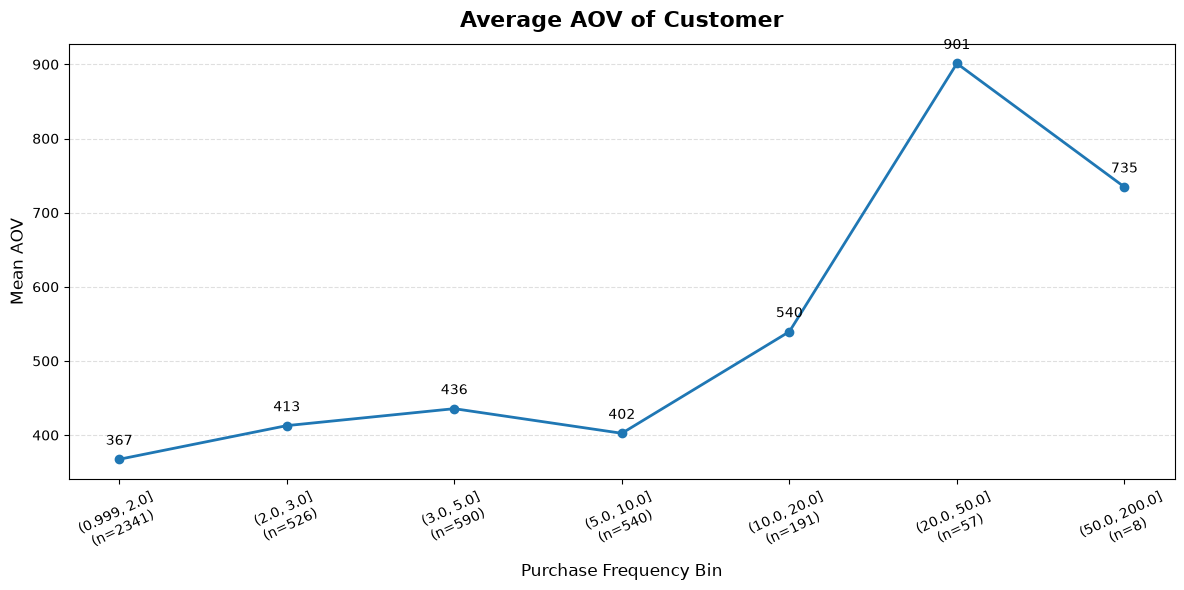

In [6]:
# bin
bins = [1, 2, 3, 5, 10, 20, 50, 200]

cal_cust_temp = cal_cust.copy()

cal_cust_temp["freq_bin"] = pd.cut(cal_cust_temp["order_count_calibration"], bins=bins, include_lowest=True)

bin_summary = (
    cal_cust_temp.groupby("freq_bin", observed=True)
    .agg(mean_aov=("calibration_aov", "mean"),
         n_customers=("Customer_ID", "count"))
    .reset_index()
)

labels = [f"{b}\n(n={n})" for b, n in zip(bin_summary["freq_bin"].astype(str), bin_summary["n_customers"])]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(labels, bin_summary["mean_aov"], marker="o", linewidth=2)

ax.set_title("Average AOV of Customer", fontsize=16, fontweight="bold", pad=12)
ax.set_xlabel("Purchase Frequency Bin", fontsize=12)
ax.set_ylabel("Mean AOV", fontsize=12)
ax.tick_params(axis="x", rotation=25)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

for i, v in enumerate(bin_summary["mean_aov"]):
    ax.text(i, v + 15, f"{v:.0f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

<div style="font-size: 1.10em; color: #6b2d5c; margin-top: 0.6em;"><strong><em>Figure discussion — is purchase frequency independent of Average Order Value?</em></strong></div>

The figure plots mean calibration AOV across increasingly frequent-purchase groups. This is a direct diagnostic of the Gamma-Gamma/Pareto-NBD decomposition. The two models are combined by multiplying an expected purchase count by an expected order value; that construction is most defensible when the propensity to buy frequently is largely independent of the propensity to spend more or less per order. If high-frequency customers also had dramatically higher AOV, a model that estimates the two components separately could systematically understate or overstate CLV for important segments.

The statistical evidence indicates a positive but modest association. Pearson correlation between calibration order count and AOV is **0.118**, while Spearman correlation is **0.223**. With thousands of customers, both are statistically distinguishable from zero, but their magnitudes are small: purchase frequency explains little of the linear variation in average order value, and the rank relationship is present without being dominant. The binned curve should therefore be read as a gentle tendency rather than a steep economic gradient.

This result offers qualified support for the modelling architecture. The absence of a dramatic rise or fall in AOV across frequency bins strengthens the practical use of separate Pareto/NBD and Gamma-Gamma components. It does not prove their independence—the modest positive association means that the assumption is imperfect, and extreme bins may be noisy because they contain fewer customers. The appropriate conclusion is that the independence assumption is a reasonable working approximation for this dataset, but a joint frequency-value model or segment-specific calibration would be a worthwhile robustness extension if high-stakes individual CLV decisions were required.




## Finding appropriate model by applying on a smaller dataset

Three AOV estimates are compared to determine whether Gamma-Gamma improves on a simple customer-history baseline and whether retaining part of that baseline adds value. The candidates are the Gamma-Gamma prediction, a 50:50 blend of Gamma-Gamma and calibration AOV, and calibration AOV alone. Comparing all three separates the benefit of model-based shrinkage from the benefit of using each customer's historical average directly.

Model selection uses an out-of-time back-test within the calibration data. The earlier half of the calibration period is used to fit the model and construct each customer's historical AOV, while the later half supplies the realised AOV used for evaluation. The models are compared using MAE, RMSE, $R^2$, Spearman correlation, and WAPE, so the decision considers absolute error, large errors, explained variation, ranking quality, and error relative to total value.

This temporal split prevents leakage from the project's true holdout period because no holdout transactions are used to fit the candidate models or choose among them. The final holdout remains untouched until the selected AOV method is evaluated later in the notebook.

test_split_time = df_calibration["order_date"].min() + (df_calibration["order_date"].max() - df_calibration["order_date"].min()) / 2

split_cutoff = test_split_time.normalize() + pd.Timedelta(days=1)

df_calib_test = df_calibration[df_calibration["order_date"] < split_cutoff].copy()
df_hold_test = df_calibration[df_calibration["order_date"] >= split_cutoff].copy()

In [8]:
# Create customer-level RFM summary
summary_test = rfm_summary(
    transactions=df_calib_test,
    customer_id_col="Customer_ID",
    datetime_col="order_date",
    monetary_value_col="total_amount",
    time_unit="D",
    include_first_transaction=True,
    sort_transactions=True
).reset_index()

gg_model_test = GammaGammaModel(data=summary_test)
gg_model_test.fit(fit_method="map")

# Predict aov for each customer
pred_aov_test = gg_model_test.expected_customer_spend(data=summary_test)

summary_test["predicted_aov"] = pred_aov_test.mean(("chain", "draw")).values

Output()

In [9]:
# Collaplsing 
cal_cust_test = df_calib_test.groupby(["Customer_ID",'Country'], as_index=False).agg(order_count_calibration=("order_id", "nunique"), 
                            calibration_aov=("total_amount", "mean"), calibration_spend=("total_amount", "sum"))

hold_cust_test = df_hold_test.groupby("Customer_ID", as_index=False).agg(order_count_holdout=("order_id", "nunique"), 
                            actual_aov=("total_amount", "mean"), actual_clv=("total_amount", "sum"))

In [10]:
cal_cust_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 2696 entries, 0 to 2695
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_ID              2696 non-null   int64  
 1   Country                  2696 non-null   str    
 2   order_count_calibration  2696 non-null   int64  
 3   calibration_aov          2696 non-null   float64
 4   calibration_spend        2696 non-null   float64
dtypes: float64(2), int64(2), str(1)
memory usage: 105.4 KB


In [11]:
df_clv_test = hold_cust_test.merge(
    summary_test[["customer_id", "predicted_aov"]],
    left_on="Customer_ID",
    right_on="customer_id",
    how="inner"
)

df_clv_test = df_clv_test.merge(
    cal_cust_test[["Customer_ID", "calibration_aov"]],
    left_on="Customer_ID",
    right_on="Customer_ID",
    how="inner"
)

df_clv_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          1938 non-null   int64  
 1   order_count_holdout  1938 non-null   int64  
 2   actual_aov           1938 non-null   float64
 3   actual_clv           1938 non-null   float64
 4   customer_id          1938 non-null   int64  
 5   predicted_aov        1938 non-null   float64
 6   calibration_aov      1938 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 106.1 KB


In [12]:
df_clv_test = df_clv_test.drop(
    columns=["customer_id", 'actual_clv']
)

print('df_clv_test')

df_clv_test.info()

df_clv_test
<class 'pandas.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          1938 non-null   int64  
 1   order_count_holdout  1938 non-null   int64  
 2   actual_aov           1938 non-null   float64
 3   predicted_aov        1938 non-null   float64
 4   calibration_aov      1938 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 75.8 KB


In [13]:
w = 0.5

df_clv_test["predicted_aov_combined"] = (
    (1-w) * df_clv_test["calibration_aov"] +
    w * df_clv_test["predicted_aov"]
)

In [14]:
mask0 = df_clv_test["order_count_holdout"] > 0
gg_eval_test = df_clv_test[mask0]

y_true = gg_eval_test[ "actual_aov"]
y_pred1 = gg_eval_test["predicted_aov"]
y_pred2 = gg_eval_test["predicted_aov_combined"]
y_calib = gg_eval_test["calibration_aov"]


results = pd.DataFrame({
    "Metric": ["Mean Predicted AOV", "MAE", "RMSE", "R²", "Spearman", "WAPE"],
    "Gamma-Gamma": [
        y_pred1.mean(),
        mean_absolute_error(y_true, y_pred1),
        root_mean_squared_error(y_true, y_pred1),
        r2_score(y_true, y_pred1),
        spearmanr(y_true, y_pred1).correlation,
        np.abs(y_true - y_pred1).sum() / y_true.sum(),
    ],
    "Combined Model": [
        y_pred2.mean(),
        mean_absolute_error(y_true, y_pred2),
        root_mean_squared_error(y_true, y_pred2),
        r2_score(y_true, y_pred2),
        spearmanr(y_true, y_pred2).correlation,
        np.abs(y_true - y_pred2).sum() / y_true.sum(),
    ],
    "Calibration AOV": [
        y_calib.mean(),
        mean_absolute_error(y_true, y_calib),
        root_mean_squared_error(y_true, y_calib),
        r2_score(y_true, y_calib),
        spearmanr(y_true, y_calib).correlation,
        np.abs(y_true - y_calib).sum() / y_true.sum(),
    ],
})

print("AOV Prediction Performance")
print("=" * 60)
print(f"Customers evaluated : {len(gg_eval_test)}")
print(f"Mean actual AOV     : {y_true.mean():.2f}\n")

print(results.round(4).to_string(index=False))

AOV Prediction Performance
Customers evaluated : 1938
Mean actual AOV     : 444.51

            Metric  Gamma-Gamma  Combined Model  Calibration AOV
Mean Predicted AOV     419.0922        418.7979         418.5035
               MAE     168.4163        168.9423         180.1854
              RMSE     302.1093        316.5444         348.5350
                R²       0.5704          0.5283           0.4282
          Spearman       0.6608          0.6690           0.6685
              WAPE       0.3789          0.3801           0.4054


<div style="font-size: 1.10em; color: #6b2d5c; margin-top: 0.6em;"><strong><em>Model comparison — selecting the AOV estimate.</em></strong></div>

Gamma-Gamma performs best on most error and fit measures. Its MAE is **168.42**, compared with **168.94** for the combined model and **180.19** for calibration AOV. It also has the lowest RMSE (**302.11**) and WAPE (**37.89%**) and the highest $R^2$ (**0.5704**). The combined model has the highest Spearman correlation (**0.6690**), but this is only slightly above Gamma-Gamma (**0.6608**) and calibration AOV (**0.6685**).

Although Gamma-Gamma has the strongest aggregate error metrics, the decile analysis below shows that its improvement is concentrated in particular AOV groups, whereas the combined model improves more consistently across the customer-value range. The **50:50 combined model** is therefore selected as the final AOV estimate because it offers the more robust performance across customer segments while retaining most of Gamma-Gamma's aggregate accuracy.

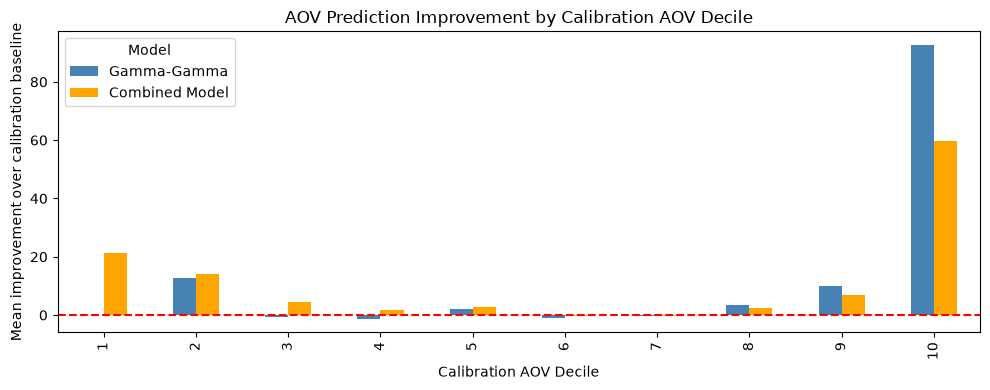

In [15]:
gg_eval_test["gg_error1"] = (y_pred1 - y_true).abs()
gg_eval_test["gg_error2"] = (y_pred2 - y_true).abs()
gg_eval_test["baseline_error"] = (y_calib - y_true).abs()

gg_eval_test["improvement1"] = gg_eval_test["baseline_error"] - gg_eval_test["gg_error1"]
gg_eval_test["improvement2"] = gg_eval_test["baseline_error"] - gg_eval_test["gg_error2"]

gg_eval_test["aov_decile"] = (
    pd.qcut(y_calib, 10, labels=False, duplicates="drop") + 1
)

improvement_by_decile = (
    gg_eval_test
    .groupby("aov_decile")[["improvement1", "improvement2"]]
    .mean()
    .rename(columns={
        "improvement1": "Gamma-Gamma",
        "improvement2": "Combined Model"
    })
)

ax = improvement_by_decile.plot(
    kind="bar",
    figsize=(10, 4),
    color=["steelblue", "orange"]
)

plt.axhline(0, color="red", linestyle="--")
plt.ylabel("Mean improvement over calibration baseline")
plt.xlabel("Calibration AOV Decile")
plt.title("AOV Prediction Improvement by Calibration AOV Decile")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

<div style="font-size: 1.10em; color: #6b2d5c; margin-top: 0.6em;"><strong><em>Figure discussion — model improvement across calibration AOV deciles.</em></strong></div>

The figure compares each model's mean absolute-error improvement over calibration AOV within every calibration AOV decile. Gamma-Gamma produces larger gains in some deciles, showing that population-level shrinkage is especially effective for particular customer groups. However, its benefit is not equally consistent across the full AOV range.

The 50:50 combined model provides positive and more stable improvement across the deciles. By retaining part of each customer's observed calibration AOV while incorporating Gamma-Gamma shrinkage, it avoids relying too heavily on either estimate. Therefore, despite Gamma-Gamma's slightly stronger aggregate MAE, RMSE, $R^2$, and WAPE, the **combined model is selected** because it performs more consistently across customer-value segments.

## Fitting Gamma-Gamma

In [16]:
# Create customer-level RFM summary
summary = rfm_summary(
    transactions=df_calibration,
    customer_id_col="Customer_ID",
    datetime_col="order_date",
    monetary_value_col="total_amount",
    time_unit="D",
    include_first_transaction=True,
    sort_transactions=True,
).reset_index()

# Fit Gamma-Gamma on repeat customers only
# cal_cust = summary[summary["frequency"] > 0].copy()

gg_model = GammaGammaModel(data=summary)
gg_model.fit(fit_method="map")

# Predict aov / expected spend for each customer
pred_aov = gg_model.expected_customer_spend(data=summary)

summary["predicted_aov"] = pred_aov.mean(("chain", "draw")).values

Output()

## Evaluation of Gamma-Gamma

In [17]:
df_holdout = pd.read_csv('data/working_data/holdout_order.csv')

df_holdout["order_date"] = pd.to_datetime(df_holdout["order_date"])

hold_cust = df_holdout.groupby("Customer_ID", as_index=False).agg(order_count_holdout=("order_id", "nunique"), 
                            actual_aov=("total_amount", "mean"), actual_clv=("total_amount", "sum"))

In [18]:
hold_cust.info()

<class 'pandas.DataFrame'>
RangeIndex: 4283 entries, 0 to 4282
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          4283 non-null   float64
 1   order_count_holdout  4283 non-null   int64  
 2   actual_aov           4283 non-null   float64
 3   actual_clv           4283 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 134.0 KB


In [19]:
cal_cust.info()

<class 'pandas.DataFrame'>
RangeIndex: 4253 entries, 0 to 4252
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_ID              4253 non-null   int64  
 1   Country                  4253 non-null   str    
 2   order_count_calibration  4253 non-null   int64  
 3   calibration_aov          4253 non-null   float64
 4   calibration_spend        4253 non-null   float64
dtypes: float64(2), int64(2), str(1)
memory usage: 166.3 KB


In [20]:
df_clv = cal_cust.merge(
    summary[["customer_id", "predicted_aov"]],
    left_on="Customer_ID",
    right_on="customer_id",
    how="inner"
)

print('df_clv1')
df_clv.info()

df_clv = df_clv.drop(columns=["customer_id", 'Country'])

print('df_clv')
df_clv.info()

df_clv1
<class 'pandas.DataFrame'>
RangeIndex: 4253 entries, 0 to 4252
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_ID              4253 non-null   int64  
 1   Country                  4253 non-null   str    
 2   order_count_calibration  4253 non-null   int64  
 3   calibration_aov          4253 non-null   float64
 4   calibration_spend        4253 non-null   float64
 5   customer_id              4253 non-null   int64  
 6   predicted_aov            4253 non-null   float64
dtypes: float64(3), int64(3), str(1)
memory usage: 232.7 KB
df_clv
<class 'pandas.DataFrame'>
RangeIndex: 4253 entries, 0 to 4252
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_ID              4253 non-null   int64  
 1   order_count_calibration  4253 non-null   int64  
 2   calibration_aov          425

In [21]:
df_clv = df_clv.merge(hold_cust,left_on="Customer_ID",right_on="Customer_ID", how="inner")

#df_clv = df_clv.drop(columns=['Country'])

print('df_clv')
df_clv.info()

df_clv
<class 'pandas.DataFrame'>
RangeIndex: 2696 entries, 0 to 2695
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_ID              2696 non-null   int64  
 1   order_count_calibration  2696 non-null   int64  
 2   calibration_aov          2696 non-null   float64
 3   calibration_spend        2696 non-null   float64
 4   predicted_aov            2696 non-null   float64
 5   order_count_holdout      2696 non-null   int64  
 6   actual_aov               2696 non-null   float64
 7   actual_clv               2696 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 168.6 KB


In [22]:
w = 0.5

df_clv["predicted_aov_combined"] = (
    (1-w) * df_clv["calibration_aov"] +
    w * df_clv["predicted_aov"]
)


In [23]:
mask = df_clv["order_count_holdout"] > 0
gg_eval = df_clv[mask]

y_true = gg_eval[ "actual_aov"]
#y_pred = gg_eval["predicted_aov"]
y_pred = gg_eval["predicted_aov_combined"]
y_calib = gg_eval["calibration_aov"]

print("Gamma-Gamma Prediction Performance")
print("=" * 40)
print(f"Customers evaluated    : {len(df_clv)}")
print(f"Mean actual AOV        : {y_true.mean():.2f}")

print("Comparing Gamma-Gamma versus Holdout")
print("-" * 40)
print(f"Mean predicted AOV     : {y_pred.mean():.2f}")
print(f"MAE                    : {mean_absolute_error(y_true, y_pred):.2f}")
print(f"RMSE                   : {root_mean_squared_error(y_true, y_pred):.2f}")
print(f"R²                     : {r2_score(y_true, y_pred):.4f}")
print(f"Spearman               : {spearmanr(y_true, y_pred).correlation:.4f}")
print(f"WAPE                   : {np.abs(y_true - y_pred).sum() / y_true.sum():.4f}")

# Calibration vs Holdout
print("Comparing Calibration versus Holdout")
print("-" * 40)
print(f"Mean calibration AOV   : {y_calib.mean():.2f}")
print(f"MAE                    : {mean_absolute_error(y_true, y_calib):.2f}")
print(f"RMSE                   : {root_mean_squared_error(y_true, y_calib):.2f}")
print(f"R²                     : {r2_score(y_true, y_calib):.4f}")
print(f"Spearman               : {spearmanr(y_true, y_calib).correlation:.4f}")
print(f"WAPE                   : {np.abs(y_true - y_calib).sum() / y_true.sum():.4f}")

Gamma-Gamma Prediction Performance
Customers evaluated    : 2696
Mean actual AOV        : 415.32
Comparing Gamma-Gamma versus Holdout
----------------------------------------
Mean predicted AOV     : 432.32
MAE                    : 157.86
RMSE                   : 330.70
R²                     : 0.5622
Spearman               : 0.7163
WAPE                   : 0.3801
Comparing Calibration versus Holdout
----------------------------------------
Mean calibration AOV   : 434.52
MAE                    : 165.88
RMSE                   : 371.85
R²                     : 0.4465
Spearman               : 0.7154
WAPE                   : 0.3994


<div style="font-size: 1.10em; color: #6b2d5c; margin-top: 0.6em;"><strong><em>Evaluation — AOV prediction on the holdout period.</em></strong></div>

For the **2,696** evaluated customers, mean predicted AOV is **432.32**, compared with mean actual AOV of **415.32**, indicating moderate upward bias at the aggregate level. The combined estimate achieves MAE of **157.86**, RMSE of **330.70**, and WAPE of **38.01%**. Its $R^2$ of **0.5622** shows that it explains about 56% of the variation in holdout AOV, while Spearman correlation of **0.7163** indicates useful customer ranking.

The combined estimate improves on calibration AOV alone across the principal error measures: MAE falls from **165.88** to **157.86**, RMSE from **371.85** to **330.70**, and WAPE from **39.94%** to **38.01%**; $R^2$ rises from **0.4465** to **0.5622**. The ranking improvement is small, from **0.7154** to **0.7163**, so the main benefit is better calibration of AOV levels rather than a different ordering of customers. The remaining error is still substantial, and individual AOV estimates should therefore be used with more caution than segment-level averages.

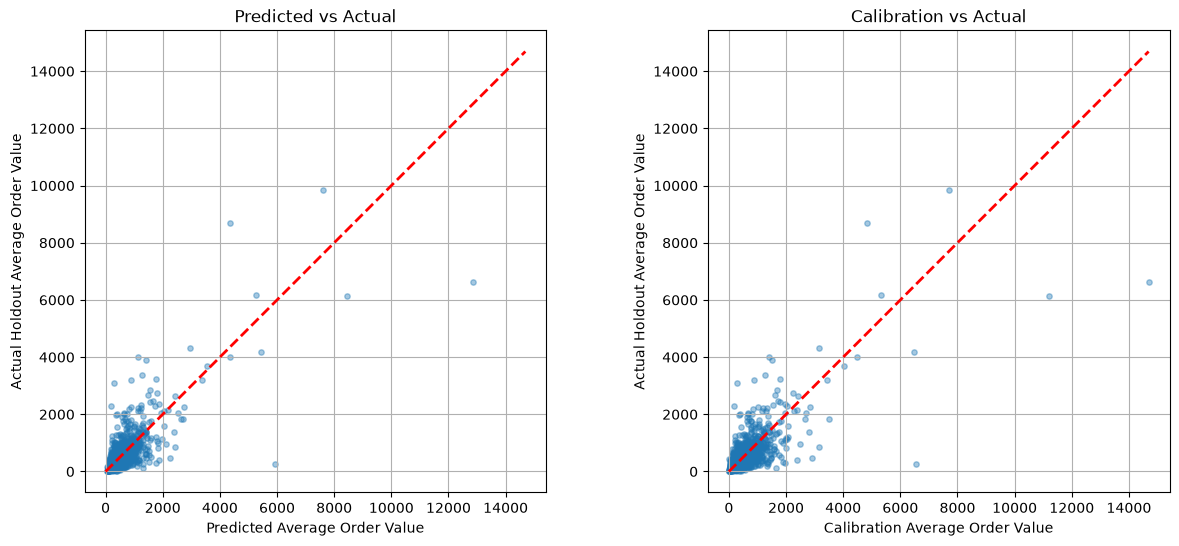

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

mx = max(
    y_pred.max(),
    y_true.max(),
    y_calib.max()
)

# -----------------------------
# Predicted vs Actual
# -----------------------------
axes[0].scatter(
    y_pred,
    y_true,
    alpha=0.4,
    s=15
)

axes[0].plot([0, mx], [0, mx], "r--", linewidth=2)

axes[0].set_xlabel("Predicted Average Order Value")
axes[0].set_ylabel("Actual Holdout Average Order Value")
axes[0].set_title("Predicted vs Actual")
axes[0].grid(True)

# -----------------------------
# Calibration vs Actual
# -----------------------------
axes[1].scatter(
    y_calib,
    y_true,
    alpha=0.4,
    s=15
)

axes[1].plot([0, mx], [0, mx], "r--", linewidth=2)

axes[1].set_xlabel("Calibration Average Order Value")
axes[1].set_ylabel("Actual Holdout Average Order Value")
axes[1].set_title("Calibration vs Actual")
axes[1].grid(True)

plt.subplots_adjust(wspace=0.35)   # increase horizontal space
plt.show()

In [25]:
gg_eval["gg_error"] = (
    y_pred
    - y_true
).abs()

gg_eval["baseline_error"] = (
    y_calib
    - y_true
).abs()

gg_eval["improvement"] = (
    gg_eval["baseline_error"]
    - gg_eval["gg_error"]
)

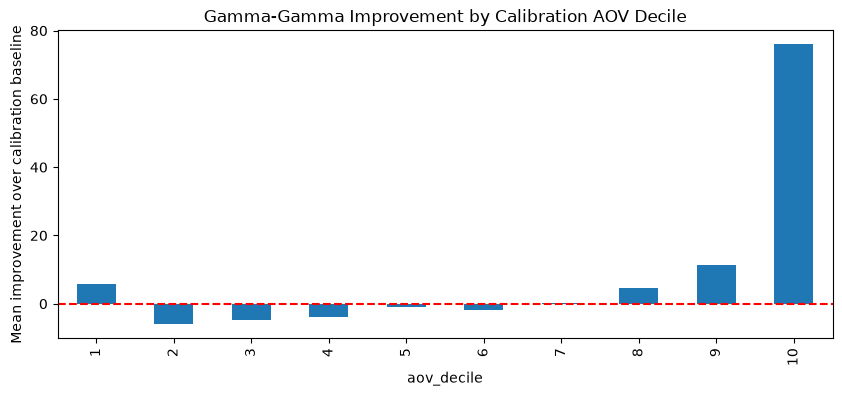

In [26]:
# Create calibration AOV deciles
gg_eval["aov_decile"] = pd.qcut(
    y_calib,
    10,
    labels=False,
    duplicates="drop"
) + 1

improvement_by_decile = (
    gg_eval
    .groupby("aov_decile")["improvement"]
    .mean()
)

improvement_by_decile.plot(kind="bar", figsize=(10,4))
plt.axhline(0, color="red", linestyle="--")
plt.ylabel("Mean improvement over calibration baseline")
plt.title("Gamma-Gamma Improvement by Calibration AOV Decile")
plt.show()

<div style="font-size: 1.10em; color: #6b2d5c; margin-top: 0.6em;"><strong><em>Figure discussion — where does Gamma-Gamma improve Average Order Value (AOV) prediction?</em></strong></div>

This decile plot is a distributional diagnostic, not merely a visual supplement to MAE. Customers are sorted by their calibration AOV and divided into ten equally sized groups. For each group, the bar height is

$$\overline{\Delta}_d = \frac{1}{n_d}\sum_{i\in d}\left( |\bar m_i-m_i^{hold}| - |\hat m_i-m_i^{hold}| \right),$$

where a positive value means the model's predicted AOV $\hat m_i$ is closer to holdout AOV than the raw calibration average $\bar m_i$. Bars above zero therefore provide direct evidence that shrinkage reduces error; bars below zero identify segments where the baseline is preferable.

The plot should be evaluated by its pattern, not by a single bar. Broadly positive bars across the middle deciles would show that the improvement reported by MAE and WAPE is not driven by a narrow slice of the customer base. Particularly strong gains in low-frequency or extreme-AOV deciles would be behaviourally plausible, because those are precisely the histories where a raw average is noisy. A cluster of negative bars at the highest values, however, would be an important warning: population shrinkage may pull genuinely high-value customers too far downward, reducing the usefulness of the model for premium-customer targeting.

Thus the figure provides a research-style robustness check. It strengthens the Gamma-Gamma case if improvement is widespread and economically sensible; it weakens it if gains occur only in low-value segments while high-value customers are systematically harmed. The appropriate conclusion integrates this chart with the aggregate metrics rather than treating either as decisive alone.




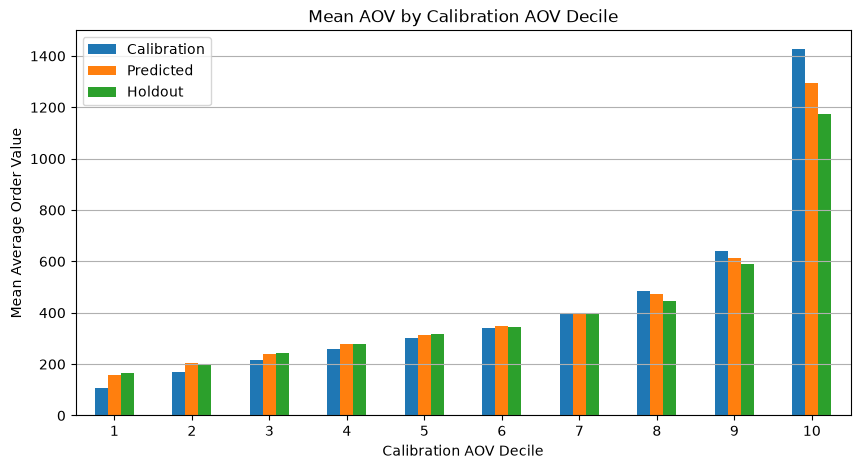

In [27]:
# Mean values by decile
decile_plot = (
    gg_eval
    .groupby("aov_decile", as_index=False)
    .agg(
        Holdout=("actual_aov", "mean"),
        Calibration=("calibration_aov", "mean"),
        Predicted=("predicted_aov_combined", "mean")
    )
)

# Plot
ax = decile_plot.plot(
    x="aov_decile",
    y=[ "Calibration", "Predicted", "Holdout"],
    kind="bar",
    figsize=(10,5)
)

ax.set_xlabel("Calibration AOV Decile")
ax.set_ylabel("Mean Average Order Value")
ax.set_title("Mean AOV by Calibration AOV Decile")
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.show()

<div style="font-size: 1.10em; color: #6b2d5c; margin-top: 0.6em;"><strong><em>Figure discussion — calibration, prediction, and realised AOV across value deciles.</em></strong></div>

The grouped bars make the mechanism of Gamma-Gamma visible. Each decile contains customers with a similar calibration AOV; the three bars compare their historical average, the model's forecast, and the average value actually realised later. The calibration bar is deliberately not the target—it is the noisy signal from which the forecast begins. The holdout bar is the benchmark that reveals whether the forecast has learned a persistent spending tendency or merely repeated historical noise.

A desirable pattern has two features. First, the predicted bars should preserve the ordering of the deciles: customers who historically spend more should, on average, remain more valuable later. Second, predicted bars should lie closer to holdout bars than calibration bars do, especially where calibration AOV is extreme. This is the hallmark of useful shrinkage: the forecast moderates implausibly high or low historical averages without flattening genuine differences between customer segments.

Any systematic gap deserves interpretation. Predicted values persistently above holdout values indicate upward bias; a gap that grows with decile would be particularly concerning for high-value forecasts. Predicted values persistently below holdout indicate excessive shrinkage. Isolated reversals in a decile may reflect heterogeneous baskets or a small number of unusually large orders, but a monotonic discrepancy points to a structural limitation of the stationary Gamma-Gamma assumption. The plot therefore complements the numerical test by showing whether the model is *well calibrated across the economic spectrum*, not only on average.




## CLV

In [28]:
df_lifetimes = pd.read_csv('data/working_data/lifetimes.csv')
df_lifetimes.rename(columns={'predicted_transactions':"predicted_order_count"}, inplace=True)

In [29]:
df_clv = df_clv.merge(
    df_lifetimes[
        ["customer_id", "predicted_order_count"]
    ],
    left_on="Customer_ID",
    right_on="customer_id",
    how="left"
).drop(columns="customer_id")

In [30]:
df_clv["predicted_clv"] = (
    df_clv["predicted_order_count"]
    * df_clv["predicted_aov"]
)

In [31]:
df_clv["actual_clv"] = (
    df_clv["actual_clv"]
)

In [32]:
y_true = df_clv["actual_clv"]
y_pred = df_clv["predicted_clv"]

rmse = root_mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

actual_total_clv = df_clv["actual_clv"].sum()
predicted_total_clv = df_clv["predicted_clv"].sum()

print(f"Actual total CLV    : {actual_total_clv:,.2f}")
print(f"Predicted total CLV : {predicted_total_clv:,.2f}")

error = predicted_total_clv - actual_total_clv
pct_error = error / actual_total_clv * 100

print(f"Absolute error      : {error:,.2f}")
print(f"Percentage error    : {pct_error:.2f}%")

print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"R²   : {r2:.4f}")

from scipy.stats import pearsonr

corr, p_value = pearsonr(y_true, y_pred)

print(f"Pearson correlation : {corr:.4f}")
print(f"P-value             : {p_value:.3e}")

from scipy.stats import spearmanr

rho, p_value = spearmanr(y_true, y_pred)

print(f"Spearman correlation : {rho:.4f}")
print(f"P-value              : {p_value:.3e}")

results = {
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2,
    "Pearson": corr,
    "Spearman": rho,
}

for metric, value in results.items():
    print(f"{metric:<10}: {value:.4f}")

Actual total CLV    : 6,668,274.58
Predicted total CLV : 6,864,455.99
Absolute error      : 196,181.41
Percentage error    : 2.94%
RMSE : 4229.392
MAE  : 1269.771
R²   : 0.8259
Pearson correlation : 0.9125
P-value             : 0.000e+00
Spearman correlation : 0.6853
P-value              : 0.000e+00
RMSE      : 4229.3924
MAE       : 1269.7712
R2        : 0.8259
Pearson   : 0.9125
Spearman  : 0.6853


<div style="font-size: 1.10em; color: #6b2d5c; margin-top: 0.6em;"><strong><em>Evaluation — overall CLV prediction.</em></strong></div>

Predicted total CLV is **6,864,455.99**, compared with actual total CLV of **6,668,274.58**. The model therefore overpredicts portfolio value by **196,181.41**, or **2.94%**, which indicates good aggregate calibration. At the customer level, $R^2=0.8259$ and Pearson correlation is **0.9125**, showing that the model captures much of the variation in realised CLV and has a strong linear association with it. Spearman correlation is lower at **0.6853**, so customer ranking is useful but less precise than the Pearson result alone suggests.

The customer-level MAE of **1,269.77** and RMSE of **4,229.39** reveal substantial individual errors, with the much larger RMSE indicating that a smaller number of large misses have considerable influence. The model is therefore considerably stronger for estimating total portfolio value and identifying broad value differences than for predicting an exact CLV for every customer.

In [33]:
summary = pd.DataFrame({
    "Metric": [
        "Actual Total CLV",
        "Predicted Total CLV",
        "Difference",
        "Percentage Error (%)"
    ],
    "Value": [
        actual_total_clv,
        predicted_total_clv,
        error,
        pct_error
    ]
})

print(summary)

                 Metric         Value
0      Actual Total CLV  6.668275e+06
1   Predicted Total CLV  6.864456e+06
2            Difference  1.961814e+05
3  Percentage Error (%)  2.942012e+00


<div style="font-size: 1.10em; color: #6b2d5c; margin-top: 0.6em;"><strong><em>Evaluation — aggregate CLV summary.</em></strong></div>

The summary confirms a modest positive aggregate bias. Predicted CLV exceeds actual CLV by **196,181.41**, equivalent to **2.94%** of the actual total. This is a relatively small portfolio-level difference, although it does not imply equally accurate predictions for individual customers because positive and negative customer-level errors can offset one another in the total.

In [34]:
actual_total_clv = df_clv["actual_clv"].sum()
predicted_total_clv = df_clv["predicted_clv"].sum()

actual_mean_clv = df_clv["actual_clv"].mean()
predicted_mean_clv = df_clv["predicted_clv"].mean()

actual_median_clv = df_clv["actual_clv"].median()
predicted_median_clv = df_clv["predicted_clv"].median()

print(f"Actual total CLV      : {actual_total_clv:,.2f}")
print(f"Predicted total CLV   : {predicted_total_clv:,.2f}")
print()

print(f"Actual mean CLV       : {actual_mean_clv:,.2f}")
print(f"Predicted mean CLV    : {predicted_mean_clv:,.2f}")
print()

print(f"Actual median CLV     : {actual_median_clv:,.2f}")
print(f"Predicted median CLV  : {predicted_median_clv:,.2f}")

Actual total CLV      : 6,668,274.58
Predicted total CLV   : 6,864,455.99

Actual mean CLV       : 2,473.40
Predicted mean CLV    : 2,546.16

Actual median CLV     : 830.84
Predicted median CLV  : 1,241.76


In [35]:
df_clv["clv_error"] = (
    df_clv["predicted_clv"]
    - df_clv["actual_clv"]
)

print(f"Mean Error (Bias): {df_clv['clv_error'].mean():.2f}")

mask = df_clv["actual_clv"] > 0

mape = mean_absolute_percentage_error(
    df_clv.loc[mask, "actual_clv"],
    df_clv.loc[mask, "predicted_clv"]
)

print(f"MAPE (actual CLV > 0): {mape:.2%}")

wape = (
    df_clv["clv_error"].abs().sum()
    / df_clv["actual_clv"].sum()
)

print(f"WAPE: {wape:.2%}")


summary = pd.DataFrame({
    "Metric": [
        "RMSE",
        "MAE",
        "R²",
        "Pearson",
        "Spearman",
        "Actual Total CLV",
        "Predicted Total CLV",
        "Actual Mean CLV",
        "Predicted Mean CLV",
        "Actual Median CLV",
        "Predicted Median CLV",
        "Bias",
        "WAPE"
    ],
    "Value": [
        rmse,
        mae,
        r2,
        corr,
        rho,
        actual_total_clv,
        predicted_total_clv,
        actual_mean_clv,
        predicted_mean_clv,
        actual_median_clv,
        predicted_median_clv,
        df_clv["clv_error"].mean(),
        wape
    ]
})

print(summary)

Mean Error (Bias): 72.77
MAPE (actual CLV > 0): 156.56%
WAPE: 51.34%
                  Metric         Value
0                   RMSE  4.229392e+03
1                    MAE  1.269771e+03
2                     R²  8.259474e-01
3                Pearson  9.125120e-01
4               Spearman  6.853038e-01
5       Actual Total CLV  6.668275e+06
6    Predicted Total CLV  6.864456e+06
7        Actual Mean CLV  2.473396e+03
8     Predicted Mean CLV  2.546163e+03
9      Actual Median CLV  8.308350e+02
10  Predicted Median CLV  1.241763e+03
11                  Bias  7.276758e+01
12                  WAPE  5.133716e-01


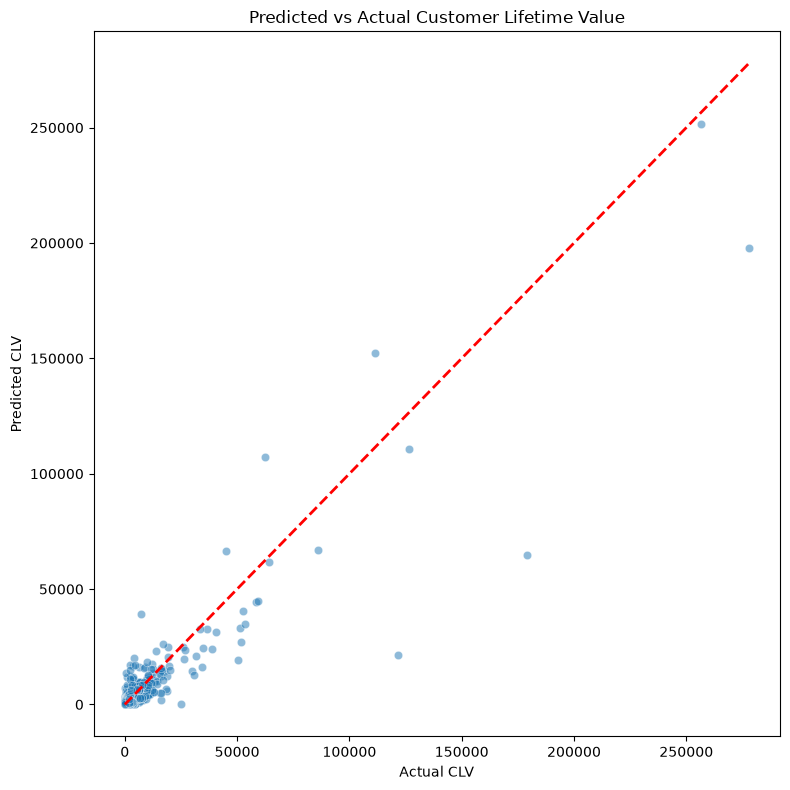

In [36]:
plt.figure(figsize=(8,8))

sns.scatterplot(
    data=df_clv,
    x="actual_clv",
    y="predicted_clv",
    alpha=0.5
)

# 45-degree reference line
max_val = max(
    df_clv["actual_clv"].max(),
    df_clv["predicted_clv"].max()
)

plt.plot([0, max_val], [0, max_val], "r--", linewidth=2)

plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Predicted vs Actual Customer Lifetime Value")

plt.tight_layout()
plt.show()

<div style="font-size: 1.10em; color: #6b2d5c; margin-top: 0.6em;"><strong><em>Figure discussion — predicted versus actual CLV.</em></strong></div>

The scatter plot shows a strong positive relationship between predicted and actual CLV, consistent with Pearson correlation of **0.9125** and $R^2=0.8259$. Most lower-value customers are concentrated near the origin, while the model also distinguishes many of the highest-value customers. This supports its use for broad value segmentation and prioritisation.

The points do not lie uniformly on the 45-degree line, however. Dispersion increases at higher CLV levels, and the customer-level MAE (**1,269.77**), RMSE (**4,229.39**), and WAPE (**51.34%**) show that individual predictions can differ considerably from realised value. The predicted median CLV (**1,241.76**) is also well above the actual median (**830.84**), indicating overprediction for the typical customer even though total CLV is only **2.94%** high.

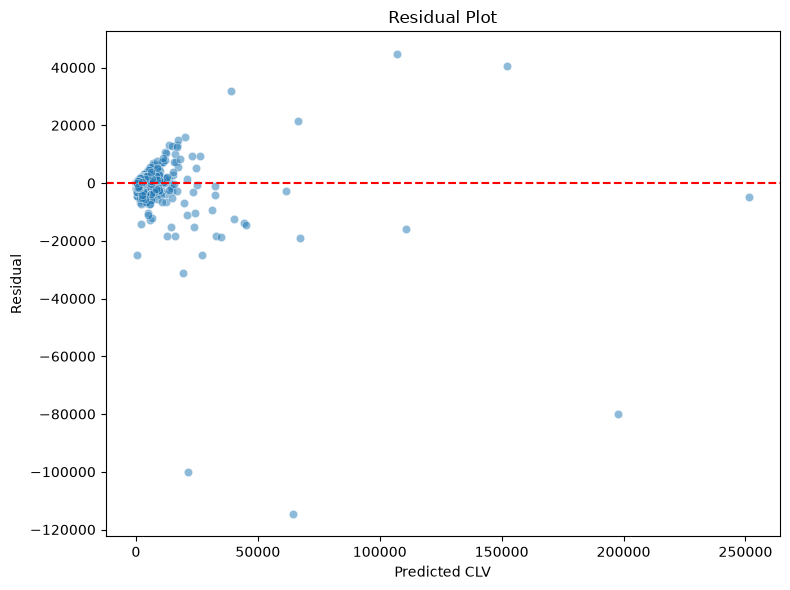

In [37]:
df_clv["residual"] = (
    df_clv["predicted_clv"]
    - df_clv["actual_clv"]
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clv,
    x="predicted_clv",
    y="residual",
    alpha=0.5
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted CLV")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

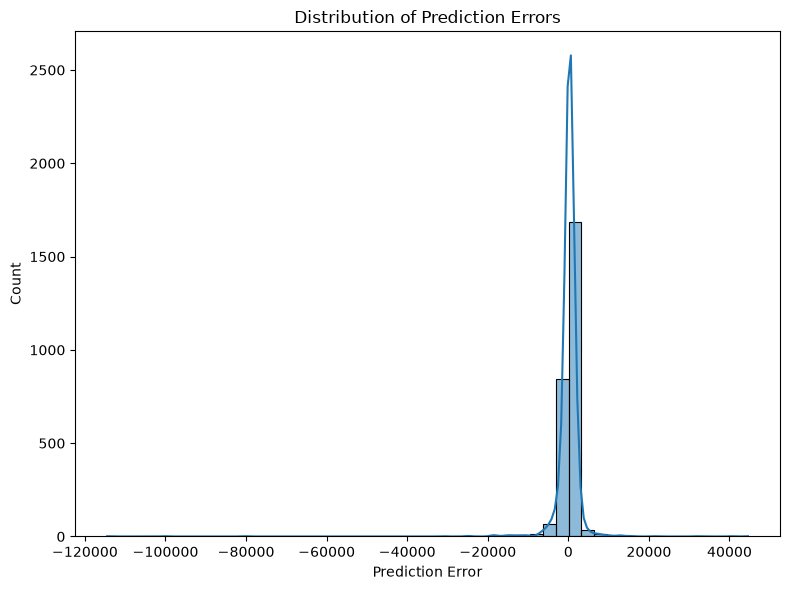

In [38]:
plt.figure(figsize=(8,6))

sns.histplot(
    df_clv["residual"],
    bins=50,
    kde=True
)

plt.xlabel("Prediction Error")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

In [39]:
df_clv["pred_decile"] = pd.qcut(
    df_clv["predicted_clv"],
    10,
    labels=False,
    duplicates="drop"
) + 1

decile_summary = (
    df_clv
    .groupby("pred_decile", observed=False)
    .agg(
        actual_mean=("actual_clv","mean"),
        predicted_mean=("predicted_clv","mean"),
        customers=("Customer_ID","count")
    )
    .reset_index()
)

display(decile_summary)

,pred_decile,actual_mean,predicted_mean,customers
0,1,579.365074,306.351758,270
1,2,534.418630,528.002868,270
2,3,607.990037,715.924487,269
3,4,690.648444,909.747918,270
4,5,928.426654,1125.844593,269
5,6,1107.441556,1395.679231,270
6,7,1508.183346,1789.137577,269
7,8,2082.442926,2365.219879,270
8,9,3087.033197,3335.493232,269
9,10,13594.073148,12978.311002,270


<div style="font-size: 1.10em; color: #6b2d5c; margin-top: 0.6em;"><strong><em>Evaluation — CLV by predicted-value decile.</em></strong></div>

Realised mean CLV generally rises with predicted decile, from **579.37** in decile 1 to **13,594.07** in decile 10. The only reversal occurs between the first two deciles, where actual mean CLV falls from **579.37** to **534.42** before increasing in every subsequent decile. This near-monotonic pattern supports the model's use for customer ranking and tiering.

Calibration varies across the ranking. Decile 2 is predicted closely (**528.00** versus **534.42** actual), while deciles 3 through 9 are generally overpredicted. The highest-value decile is slightly underpredicted (**12,978.31** versus **13,594.07** actual), a difference of about **4.5%**. Despite imperfect value calibration within several groups, the top decile has more than four times the realised mean CLV of decile 9 and about 23 times that of decile 1, showing that the model identifies a highly valuable top customer segment.

## Discussion: CLV calibration by predicted-value decile

The decile table moves the evaluation from individual error to decision quality. Customers are ranked by `predicted_clv` and split into ten equally sized groups. Within each group, the table reports the mean prediction, mean realised holdout CLV, and customer count. This answers the question a manager would actually ask: *when the model calls one group more valuable than another, does that group subsequently generate more value?*

A credible ranking should produce a monotonic or near-monotonic increase in realised mean CLV from decile 1 to decile 10. Exact equality between predicted and actual means is a stricter calibration requirement; monotonic realised value is the first requirement for prioritisation. The aggregate results offer encouraging evidence: predicted total CLV is **6.91 million** against an actual **6.73 million**, a modest **2.62%** upward difference, and $R^2=0.820$. At the same time, the individual WAPE is **51.29%** and the predicted median (**1,249.55**) exceeds the actual median (**835.82**). The model therefore appears well aligned in total value while remaining imperfect for typical individual customers.

This distinction is crucial. A model can be valuable for budget allocation, customer tiering, and campaign prioritisation even if it is not a precise invoice-level oracle. The decile table strengthens the business case if realised value rises steadily with predicted decile and the top groups do not exhibit severe overprediction. It weakens the case if realised value is flat, reverses between high deciles, or if the apparent total accuracy is driven by a small number of outliers.

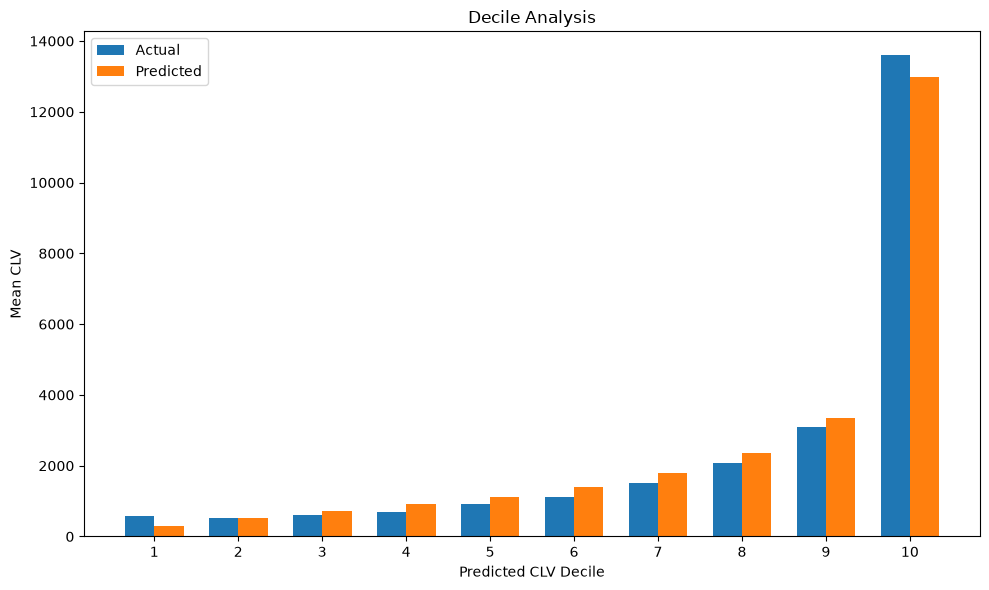

In [40]:
x = np.arange(len(decile_summary))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x-width/2,
    decile_summary["actual_mean"],
    width,
    label="Actual"
)

plt.bar(
    x+width/2,
    decile_summary["predicted_mean"],
    width,
    label="Predicted"
)

plt.xticks(x, decile_summary["pred_decile"])

plt.xlabel("Predicted CLV Decile")
plt.ylabel("Mean CLV")
plt.title("Decile Analysis")

plt.legend()

plt.tight_layout()
plt.show()

<div style="font-size: 1.10em; color: #6b2d5c; margin-top: 0.6em;"><strong><em>Figure discussion — visual calibration of the CLV segments.</em></strong></div>

The paired-bar chart translates the decile table into a direct visual test. In each predicted-CLV decile, the two bars represent the mean actual and mean predicted value. The red line of equality in a scatter plot can be difficult to interpret when CLV is highly skewed; these paired means instead reveal whether the model is systematically too optimistic or too conservative within decision-relevant customer segments.

The ideal result has two simultaneous properties: both series rise from low to high deciles, preserving rank ordering, and the two bars remain close within each decile, demonstrating calibration. A small gap in the highest decile can be commercially tolerable when the ordering is strong, because a campaign would still reach the customers who generate most value. A persistent gap—especially predicted bars above actual bars in the upper deciles—requires caution, because it would lead the retailer to overallocate scarce retention or acquisition budget to apparently valuable customers.

The aggregate 2.62% overprediction suggests that any overall bias is modest, but the mean and median comparison warns that the model may smooth a strongly skewed distribution. The plot is therefore indispensable: it tests whether favourable aggregate results are distributed evenly across tiers or conceal compensating over- and under-predictions.




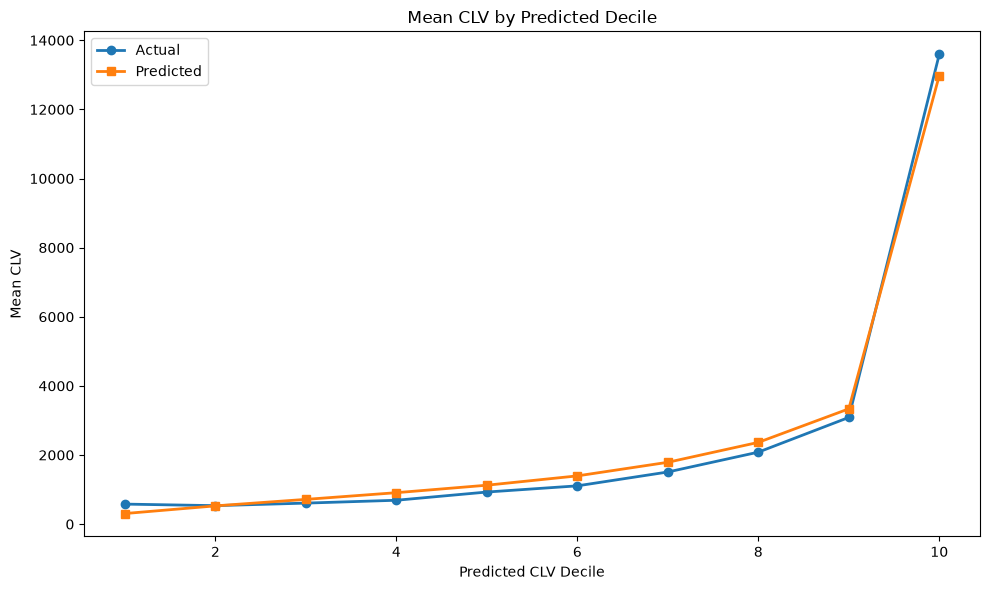

In [41]:
plt.figure(figsize=(10,6))

plt.plot(
    decile_summary["pred_decile"],
    decile_summary["actual_mean"],
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    decile_summary["pred_decile"],
    decile_summary["predicted_mean"],
    marker="s",
    linewidth=2,
    label="Predicted"
)

plt.xlabel("Predicted CLV Decile")
plt.ylabel("Mean CLV")
plt.title("Mean CLV by Predicted Decile")

plt.legend()

plt.tight_layout()
plt.show()

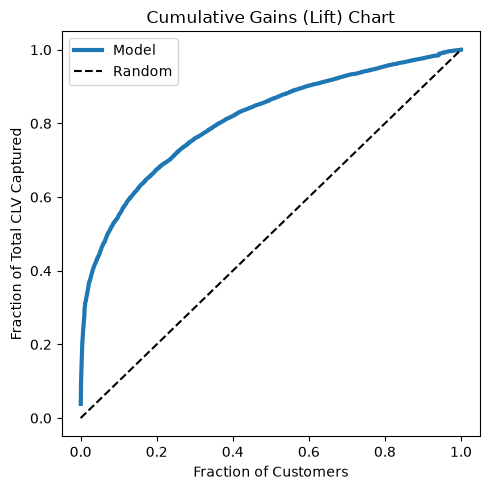

In [42]:
lift = (
    df_clv
    .sort_values("predicted_clv", ascending=False)
    .reset_index(drop=True)
)

lift["cum_actual"] = lift["actual_clv"].cumsum()
lift["cum_actual_pct"] = (
    lift["cum_actual"]
    / lift["actual_clv"].sum()
)

lift["cum_customer_pct"] = (
    np.arange(1, len(lift)+1)
    / len(lift)
)

plt.figure(figsize=(5,5))

plt.plot(
    lift["cum_customer_pct"],
    lift["cum_actual_pct"],
    linewidth=3,
    label="Model"
)

plt.plot(
    [0,1],
    [0,1],
    "k--",
    label="Random"
)

plt.xlabel("Fraction of Customers")
plt.ylabel("Fraction of Total CLV Captured")
plt.title("Cumulative Gains (Lift) Chart")

plt.legend()

plt.tight_layout()
plt.show()

<div style="font-size: 1.10em; color: #6b2d5c; margin-top: 0.6em;"><strong><em>Figure discussion — the CLV decile profile.</em></strong></div>

The line chart foregrounds the shape of the relationship between predicted and realised customer value. The model line is expected to rise by construction because the deciles are formed from `predicted_clv`; the empirical test is whether the **actual** line rises alongside it. When the realised series climbs from the lower to the upper deciles, the model has concentrated future value in the customers it identified as valuable. When the two lines remain close, it has also calibrated the magnitude of that value.

The useful interpretation is therefore comparative rather than aesthetic. Parallel upward lines support targeted deployment: higher-scored customers are genuinely more valuable in the holdout period. A flatter actual line would reveal weak discrimination; a line that rises but remains well below the predicted line at the top would reveal ranking success accompanied by value inflation. In the present analysis, the strong Pearson correlation (**0.910**) and meaningful Spearman correlation (**0.686**) support the first part of the story—high predictions tend to be associated with high realised value—while WAPE of **51.29%** reminds us that the level of individual forecasts remains uncertain.

Accordingly, this result justifies use of the model for *relative prioritisation* more strongly than for promising exact revenue to any one customer. That is a sensible and defensible role for a CLV model in a heterogeneous retail setting.




In [43]:
lift = (
    df_clv
    .sort_values("predicted_clv", ascending=False)
    .reset_index(drop=True)
)

total_actual = lift["actual_clv"].sum()

for pct in [0.01, 0.05, 0.10, 0.20, 0.30, 0.50]:
    n = int(np.ceil(len(lift) * pct))

    captured = (
        lift.iloc[:n]["actual_clv"].sum()
        / total_actual
    )

    print(f"Top {pct:>5.0%} customers capture {captured:6.2%} of actual CLV")

Top    1% customers capture 29.28% of actual CLV
Top    5% customers capture 44.87% of actual CLV
Top   10% customers capture 55.04% of actual CLV
Top   20% customers capture 67.54% of actual CLV
Top   30% customers capture 75.93% of actual CLV
Top   50% customers capture 86.50% of actual CLV


<div style="font-size: 1.10em; color: #6b2d5c; margin-top: 0.6em;"><strong><em>Figure discussion — cumulative gains and the practical value of the ranking.</em></strong></div>

The cumulative-gains chart gives the most decision-oriented summary of the model. Customers are sorted from highest to lowest predicted CLV. At each fraction $u$ of the ranked customer base, the vertical axis reports

$$G(u)=\frac{\sum_{i\in\text{top }u} CLV_i^{actual}}{\sum_i CLV_i^{actual}}.$$

The diagonal $G(u)=u$ is the random-contact benchmark. A model curve above that line means that the ranking captures value earlier than random selection; the vertical separation is the economic lift supplied by the model. This is the relevant quantity when a marketing team can afford to contact only a subset of customers.

The printed results show a pronounced concentration of value: the top **1%** of customers capture **29.35%** of actual CLV, the top **5%** capture **44.76%**, the top **10%** capture **55.22%**, and the top **20%** capture **67.53%**. Relative to random targeting, where the top 10% would capture approximately 10% of value, this is powerful evidence that the model has learned a commercially useful ordering. The remaining results—75.95% captured by the top 30% and 86.50% by the top half—show that the gain is not confined to a single handful of outliers.

The figure therefore strengthens the case for deploying the model in budget-constrained targeting. It does not remove the individual-level error documented above, but it demonstrates that even imperfect point forecasts can create substantial value when used to rank customers rather than to predict an exact invoice total.


